In [3]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# **Metode Numerik untuk Masalah Nilai Awal (Initial Value Problems)**

Sekarang kita beralih ke persamaan diferensial parsial (PDE) yang bergantung pada waktu. Sebelum membahas PDE secara lengkap, kita akan terlebih dahulu mempelajari metode numerik untuk sistem persamaan diferensial biasa (ODE) yang merupakan masalah nilai awal dengan bentuk umum sebagai berikut
$$ \frac{\text{d} \vec{u}}{\text{d}t} = \vec{f}(t, \vec{u}) \quad \vec{u}(0) = \vec{u}_0 $$
Dimana
- $\vec{u}(t)$ adalah vektor keadaan (state vector)
- $\vec{f}(t, \vec{u})$ adalah fungsi bernilai vektor yang mengatur bagaimana $\vec{u}$ berubah terhadap waktu
- $\vec{u}(0)$ adalah kondisi awal pada waktu $t = 0$

dengan catatan bahwa fungsi di sisi kanan, yaitu $f$, bisa saja berasal dari proses diskretisasi ruang dari sebuah PDE, sehingga membentuk suatu sistem persamaan.

#### Contoh: Peluruhan Radioaktif Sederhana
Misalkan kita memiliki sistem dengan satu komponen
$$ \vec{u} = [c] $$
Maka sistem ODE-nya menjadi
$$\frac{\text{d} c}{\text{d}t} = -\lambda c \quad c(0) = c_0$$
dimana memiliki solusi eksak dalam bentuk $c(t) = c_0 e^{-\lambda t}$

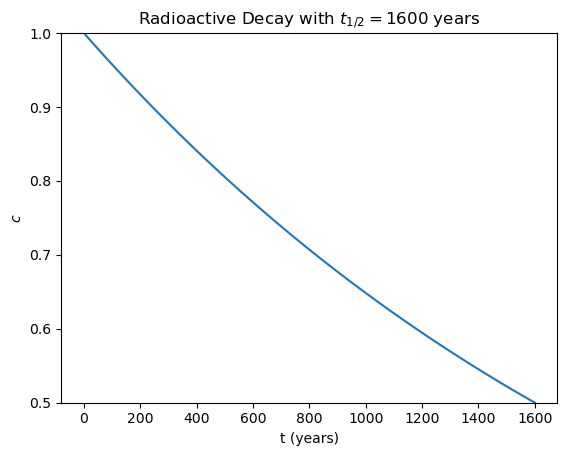

In [9]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, 1.0 * numpy.exp(-decay_constant * t))

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_ylim((0.5,1.0))
plt.show()

#### Contoh: Peluruhan Radioaktif Kompleks (atau Sistem Kimia)
Pertimbangkan rantai peluruhan dari satu spesies ke spesies lainnya. Sistemnya dapat dimodelkan dengan persamaan diferensial berikut
$$\begin{aligned}
    \frac{\text{d} c_1}{\text{d}t} &= -\lambda_1 c_1 \\
    \frac{\text{d} c_2}{\text{d}t} &= \lambda_1 c_1 - \lambda_2 c_2 \\
    \frac{\text{d} c_2}{\text{d}t} &= \lambda_2 c_3 - \lambda_3 c_3 
\end{aligned}$$
Sistem ini bisa ditulis dalam bentuk vektor sebagai
$$\frac{\text{d} \vec{u}}{\text{d}t} = \frac{\text{d}}{\text{d}t}\begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix} = 
\begin{bmatrix} 
    -\lambda_1 & 0 & 0 \\
    \lambda_1 & -\lambda_2 & 0 \\
    0 & \lambda_2 & -\lambda_3
\end{bmatrix} \begin{bmatrix} c_1 \\ c_2 \\ c_3 \end{bmatrix}$$
atau secara ringkas 
$$\frac{\text{d} \vec{u}}{\text{d}t} = A \vec{u}$$
Untuk sistem persamaan seperti ini, solusi umum dari ODE tersebut dinyatakan dengan eksponensial matriks
$$\vec{u}(t) = \vec{u}_0 e^{A t}$$
Artinya, perubahan keadaan sistem terhadap waktu dapat dihitung dengan mengalikan kondisi awal u dengan eksponensial dari matriks 
𝐴 dikalikan waktu 𝑡. Ini sangat umum dalam sistem peluruhan berantai atau reaksi kimia bertahap

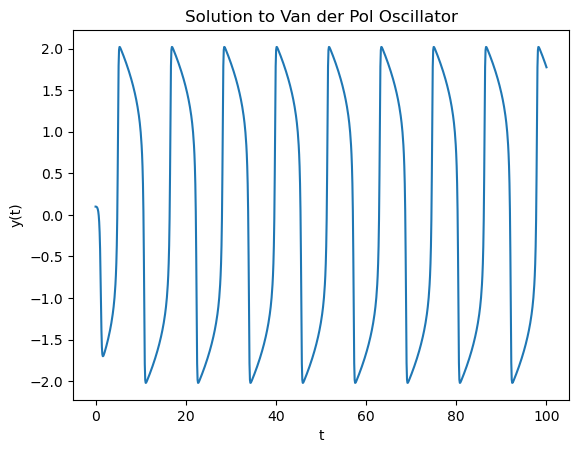

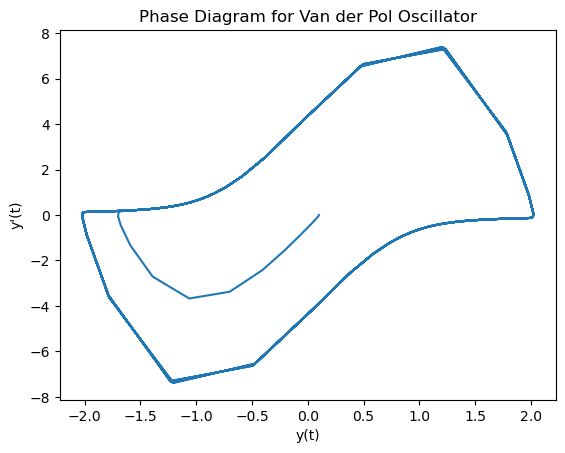

In [15]:
import scipy.integrate as integrate

def f(t, u, mu=5):
    return numpy.array([u[1], mu * (1.0 - u[0]**2) * u[1] - u[0]])

t = numpy.linspace(0.0, 100, 1000)
u = numpy.empty((2, t.shape[0]))
u[:, 0] = [0.1, 0.0]

integrator = integrate.ode(f)
integrator.set_integrator("dopri5")
integrator.set_initial_value(u[:, 0])

for (n, t_n) in enumerate(t[1:]):
    integrator.integrate(t_n)
    if not integrator.successful():
        break
    u[:, n + 1] = integrator.y
    
fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(t, u[0,:])
axes.set_title("Solution to Van der Pol Oscillator")
axes.set_xlabel("t")
axes.set_ylabel("y(t)")

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)

axes.plot(u[0,:], u[1, :])
axes.set_title("Phase Diagram for Van der Pol Oscillator")
axes.set_xlabel("y(t)")
axes.set_ylabel("y'(t)")

plt.show()

#### Contoh: Persamaan Panas (Heat Equation)
Sekarang kita akan membangun sistem ODE yang merepresentasikan persamaan panas
$$ u_t = u_{xx} $$
Jika kita melakukan diskretisasi terhadap turunan spasial $u_xx$ menggunakan finite difference orde dua dengan skema pusat (centered difference), dan menggunakan $m$ titik diskretisasi di ruang, maka kita dapatkan
$$ \frac{\text{d}}{\text{d} t} U_i(t) = \frac{U_{i+1}(t) - 2 U_i(t) + U_{i-1}(t)}{\Delta x^2} $$
Dengan cara ini, kita mengubah PDE menjadi sistem ODE sebanyak $m$ buah persamaan terhadap waktu. Pendekatan ini dikenal sebagai metode garis (method of lines) — yaitu kita mendiskretkan semua variabel kecuali waktu, sehingga menghasilkan sistem ODE yang bisa diselesaikan dengan metode numerik seperti Euler, Runge-Kutta, dll.

### **Eksistensi dan Keunikan Solusi**
Sebelum masuk ke metode numerik untuk menyelesaikan masalah nilai awal (IVP) pada ODE, langkah penting yang perlu dipahami terlebih dahulu adalah bagaimana sifat solusi dari persamaan tersebut. apakah solusinya benar-benar ada, dan jika ada, apakah solusinya unik.

### Sistem Linear
Untuk ODE linear, kita memiliki bentuk umum sistem
$$  u'(t) = A(t) u + g(t) $$
enting untuk dicatat bahwa sistem linear seperti ini selalu memiliki solusi yang unik, asalkan A(t) dan g(t) kontinu pada interval waktu yang dimaksud.

### Keberadaan dan Keunikan untuk Sistem Non-Linear
#### Kekontinuan Lipschitz
Untuk memperluas konsep keunikan solusi pada ODE non-linear, dibutuhkan jenis kekontinuan khusus yang disebut kekontinuan Lipschitz (Lipschitz continuity). Pertimbangkan ODE itu
$$ u'(t) = f(u,t),  \quad \quad \quad u(t_0) = u_0 $$
Agar solusi dari persamaan ini eksis dan unik, kita tidak cukup hanya membutuhkan fungsi f(u,t) kontinu, kita juga membutuhkan fungsi tersebut memiliki tingkat "kekasaran" atau "kelicinan" tertentu, yang dalam hal ini adalah kontinuitas Lipschitz terhadap u.

Karena kita juga mengetahui solusi eksak dari ODE di atas
$$ u(t) = \frac{1}{1/u_0 - t}$$
kita dapat melihat bahwa $|u(t)| < \infty$ selama $t \neq 1/u_0$. Perlu dicatat bahwa setelah kita mencapai titik singularitas (pole) di penyebut, tidak ada lagi solusi yang mungkin untuk IVP tersebut setelah titik tersebut. 

#### Contoh 2
Pertimbangkan IVP berikut
$$ u' = \sqrt{u} \quad \quad u(0) = 0$$
Kita ingin mengetahui: di mana fungsi 𝑓(𝑢)=𝑢 bersifat Lipschitz kontinu?

### Sistem Persamaan
Konsep yang serupa untuk kontinuitas Lipschitz juga berlaku dalam norma tertentu $||\cdot||$ , jika ada suatu konstanta 𝐿 sedemikian sehingga:
$$ ||f(u,t) - f(u^\ast,t)|| \leq L ||u - u^\ast|| $$
untuk semua pasangan $(u,t)$ dan $(u^\ast,t)$ dalam domain $\Omega = \{(u,t) : ||u-u_0|| \leq a, t_0 \leq t \leq t_1 \}$.
Perhatikan bahwa jika fungsi 𝑓 bersifat Lipschitz kontinu dalam satu norma, maka 𝑓 juga akan kontinu dalam norma apapun. Ini berarti sifat Lipschitz akan tetap terjaga meskipun kita mengganti norma yang digunakan.

### **Skema Langkah Dasar**
Kembali ke pekerjaan kita tentang diferensiasi numerik, mengapa tidak mengaproksimasi turunan menggunakan beda hingga (finite difference)
$$ \frac{u(t + \Delta t) - u(t)}{\Delta t} = f(t, u)$$
Namun, kita masih perlu memutuskan bagaimana cara mengevaluasi term 𝑓(𝑡,𝑢) tersebut.
Mari kita lihat ini dari perspektif kuadratur (integrasi numerik). Ambil integral dari kedua sisi persamaan

$$\begin{aligned}
    \int^{t + \Delta t}_t \frac{\text{d} u}{\text{d}\tilde{t}} d\tilde{t} &= \int^{t + \Delta t}_t f(t, u) d\tilde{t} \\ ~ \\
u(t + \Delta t) - u(t) &= \Delta t ~f(t, u(t)) \\ ~ \\
\frac{u(t + \Delta t) - u(t)}{\Delta t} &= f(t, u(t))
\end{aligned}$$

Di sini, kita telah menggunakan aturan kuadratur kiri (left-sided quadrature rule) untuk integral pada sisi kanan. 

Dengan memperkenalkan beberapa notasi untuk menyederhanakan penulisan
$$ t_0 = 0  \quad \quad t_1 = t_0 + \Delta t  \quad \quad t_n = t_{n-1} + \Delta t = n \Delta t + t_0$$
$$ U^0 = u(t_0) \quad \quad U^1 = u(t_1) \quad \quad U^n = u(t_n)$$
Kita dapat menulis ulang skema kita sebagai
$$ \frac{U^{n+1} - U^n}{\Delta t} = f(t_n, U^n)$$
atau
$$ U^{n+1} = U^n + \Delta t f(t_n, U^n)$$
Yang dikenal sebagai metode Euler maju (forward Euler method). Secara esensial, kita mengaproksimasi turunan dengan nilai fungsi pada titik $t_n$ yang kita sedang hitung

<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
C:\Users\febia\AppData\Local\Temp\ipykernel_19928\1245662689.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)


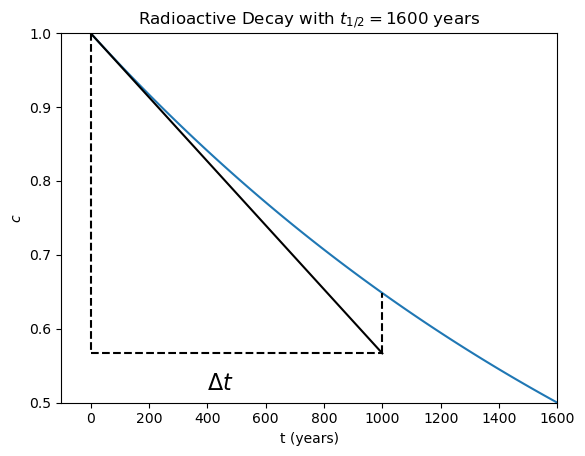

In [23]:
t = numpy.linspace(0.0, 1.6e3, 100)
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, c_0 * numpy.exp(-decay_constant * t), label="True Solution")

# Plot Euler step
dt = 1e3
u_np = c_0 + dt * (-decay_constant * c_0)
axes.plot((0.0, dt), (c_0, u_np), 'k')
axes.plot((dt, dt), (u_np, c_0 * numpy.exp(-decay_constant * dt)), 'k--')
axes.plot((0.0, 0.0), (c_0, u_np), 'k--')
axes.plot((0.0, dt), (u_np, u_np), 'k--')
axes.text(400, u_np - 0.05, '$\Delta t$', fontsize=16)

axes.set_title("Radioactive Decay with $t_{1/2} = 1600$ years")
axes.set_xlabel('t (years)')
axes.set_ylabel('$c$')
axes.set_xlim(-1e2, 1.6e3)
axes.set_ylim((0.5,1.0))
plt.show()

Gambar tersebut menunjukkan perbandingan antara solusi eksak peluruhan radioaktif (garis biru melengkung) dan pendekatan numerik menggunakan metode Euler maju (garis hitam lurus). Kurva biru menggambarkan peluruhan eksponensial yang tepat dari suatu zat radioaktif dengan waktu paruh 1600 tahun. Sementara itu, garis lurus hitam mewakili satu langkah pendekatan Euler dari titik awal $t = 0$ hingga $t = 1000$, menggunakan informasi laju perubahan hanya di titik awal tersebut. Garis-garis putus-putus hitam menunjukkan ilustrasi panjang langkah waktu ($\Delta t$) dan perbedaan nilai antara pendekatan Euler dan solusi eksak.

Perhatikan di mana kita mengharapkan adanya kesalahan karena pendekatan yang kita lakukan, dan bagaimana hal ini muncul dalam contoh di bawah ini.

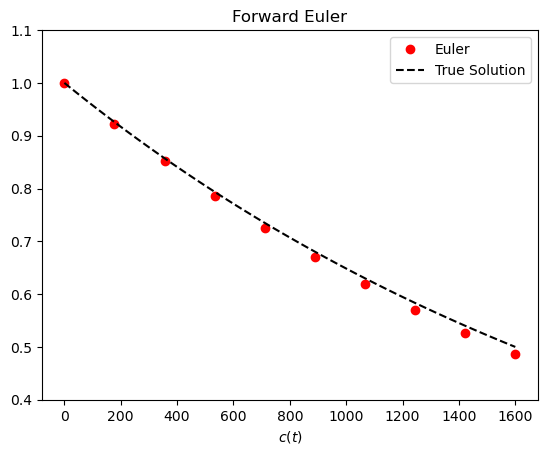

In [28]:
c_0 = 1.0
decay_constant = numpy.log(2.0) / 1600.0
f = lambda t, u: -decay_constant * u

t_exact = numpy.linspace(0.0, 1.6e3, 100)
u_exact = c_0 * numpy.exp(-decay_constant * t_exact)

# Implement Euler
t = numpy.linspace(0.0, 1.6e3, 10)
delta_t = t[1] - t[0]
U = numpy.empty(t.shape)
U[0] = c_0
for (n, t_n) in enumerate(t[:-1]):
    U[n + 1] = U[n] + delta_t * f(t_n, U[n])

fig = plt.figure()
axes = fig.add_subplot(1, 1, 1)
axes.plot(t, U, 'or', label="Euler")
axes.plot(t_exact, u_exact, 'k--', label="True Solution")

axes.set_title("Forward Euler")
axes.set_xlabel("t (years)")
axes.set_xlabel("$c(t)$")
axes.set_ylim((0.4,1.1))
axes.legend()
plt.show()

Gambar ini menunjukkan perbandingan antara hasil pendekatan numerik menggunakan **metode Euler maju** (Forward Euler) dan **solusi eksak** dari peluruhan radioaktif. Titik-titik **merah** pada grafik mewakili hasil dari metode Euler pada setiap langkah waktu, sedangkan garis **putus-putus hitam** menunjukkan kurva solusi eksak dari persamaan diferensial yang menggambarkan peluruhan eksponensial zat radioaktif. Terlihat bahwa hasil Euler mengikuti pola kurva eksak dengan cukup baik, meskipun sedikit menyimpang karena metode ini hanya menggunakan informasi dari titik sebelumnya untuk memperkirakan titik berikutnya. 
